In [1]:
%pip install -q pymssql pandas numpy scikit-learn matplotlib seaborn statsmodels python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Setup

This notebook connects to the Azure SQL database. Create a `.env` file in this directory (`MachineLearning/ml-pipelines/.env`) with:

```
DB_SERVER=lunas-project-intex-sql.database.windows.net
DB_DATABASE=lunas-project-db
DB_USERNAME=sqladmin
DB_PASSWORD=<your-password>
```

# Donor Churn Classifier

Predict which supporters are at risk of becoming inactive so the organization can prioritize retention outreach.

## 1. Problem Framing

**Business Problem:** Lighthouse Philippines has 60 supporters. The organization needs to identify which donors are likely to become inactive so retention efforts can be targeted effectively.

**Target variable:** `churn` — binary (1 = inactive supporter, 0 = active).

**Modeling Strategy:**

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* churn | Logistic Regression (statsmodels) |
| **Predictive** | Predict which donors will churn | Best classifier via sklearn Pipeline |

**Success metric:** Recall is the priority — missing an at-risk donor (false negative) is more costly than unnecessary outreach (false positive).

## 2. Data Preparation & Exploration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
SEED = 42
import re as _re

# ── Load data from seed CSVs (TA-grading notebook — no database connection) ─
from pathlib import Path

_cwd = Path.cwd().resolve()
_candidates = [
    _cwd.parent.parent / "Backend" / "Data" / "SeedData",
    _cwd.parent / "Backend" / "Data" / "SeedData",
    _cwd / "Backend" / "Data" / "SeedData",
]
SEED_DIR = next((p for p in _candidates if p.exists()), None)
if SEED_DIR is None:
    raise FileNotFoundError(
        "Could not find Backend/Data/SeedData. Run the notebook from "
        "MachineLearning/ml-pipelines/ or the repo root."
    )
print(f"Loading data from {SEED_DIR}")
conn = None  # no DB in TA-grading version; LivePipelines/ has the DB-writing copies

def load_table(table_name):
    csv_name = _re.sub(r'(?<!^)(?=[A-Z])', '_', table_name).lower() + '.csv'
    return pd.read_csv(SEED_DIR / csv_name)

# ── Load data ────────────────────────────────────────────────────────────────
supporters = load_table('Supporters')
donations  = load_table('Donations')
print(f'Supporters: {supporters.shape}')
print(f'Donations:  {donations.shape}')

# ── Feature engineering (one row per supporter) ──────────────────────────────
REFERENCE_DATE = pd.Timestamp('2026-04-06')
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
supporters['first_donation_date'] = pd.to_datetime(supporters['first_donation_date'])

don_agg = donations.groupby('supporter_id').agg(
    donation_count=('donation_id', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    last_donation_date=('donation_date', 'max'),
    first_donation_date=('donation_date', 'min'),
    unique_campaigns=('campaign_name', 'nunique'),
    donation_type_count=('donation_type', 'nunique'),
    recurring_ratio=('is_recurring', 'mean')
).reset_index()

don_agg['days_since_last_donation'] = (REFERENCE_DATE - don_agg['last_donation_date']).dt.days
don_agg['days_since_first_donation'] = (REFERENCE_DATE - don_agg['first_donation_date']).dt.days
don_agg['donation_frequency'] = don_agg['donation_count'] / (don_agg['days_since_first_donation'].clip(lower=1) / 365)
don_agg.drop(columns=['last_donation_date', 'first_donation_date',
                       'recurring_ratio'], inplace=True, errors='ignore')

# ── Merge with supporters and build target ───────────────────────────────────
df = supporters[['supporter_id', 'supporter_type', 'relationship_type',
                  'acquisition_channel', 'status']].merge(
    don_agg, on='supporter_id', how='left'
)

fill_zero = ['donation_count', 'total_amount', 'avg_amount',
             'unique_campaigns', 'donation_type_count', 'donation_frequency']
for col in fill_zero:
    df[col] = df[col].fillna(0)
df['days_since_last_donation'] = df['days_since_last_donation'].fillna(9999)
df['days_since_first_donation'] = df['days_since_first_donation'].fillna(9999)

df['churn'] = (df['status'] == 'Inactive').astype(int)
df['channel_source_mode'] = df['acquisition_channel']

# ── One-hot encode for explanatory model ─────────────────────────────────────
cat_cols = ['acquisition_channel', 'supporter_type', 'relationship_type']
df_model = pd.get_dummies(df.drop(columns=['supporter_id', 'status', 'channel_source_mode']),
                          columns=cat_cols, drop_first=True)

y = df_model['churn']
X = df_model.drop(columns=['churn'])

# ── Train/test split ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Loading data from /Users/kimballberrett/Documents/intexii/Backend/Data/SeedData
Supporters: (60, 15)
Donations:  (420, 13)
Train: (45, 20), Test: (15, 20)
Train churn rate: 24.44%
Test churn rate:  26.67%


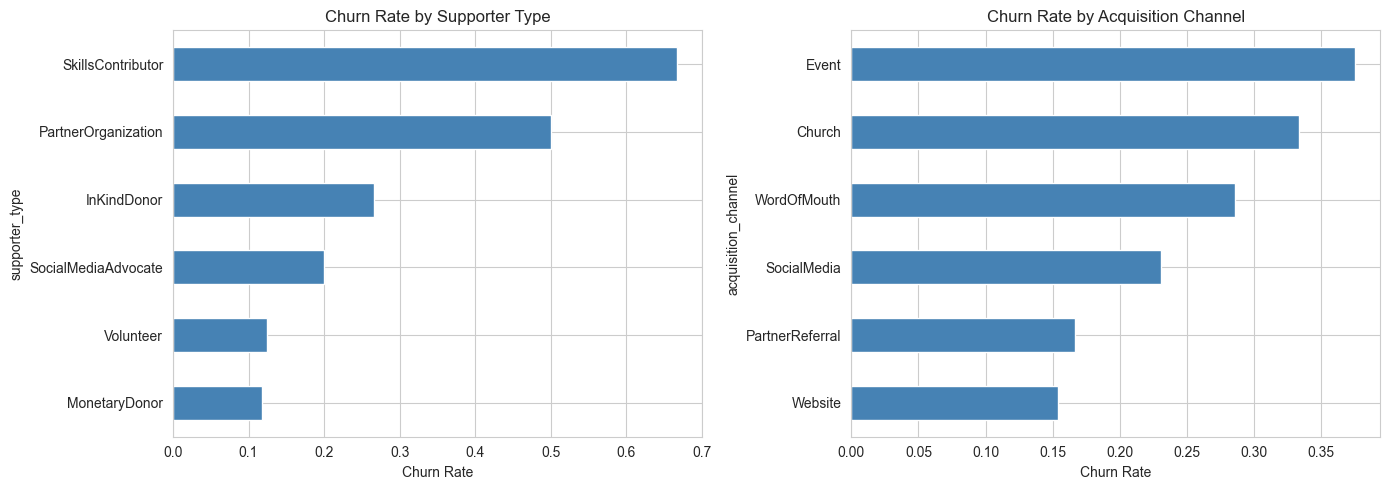

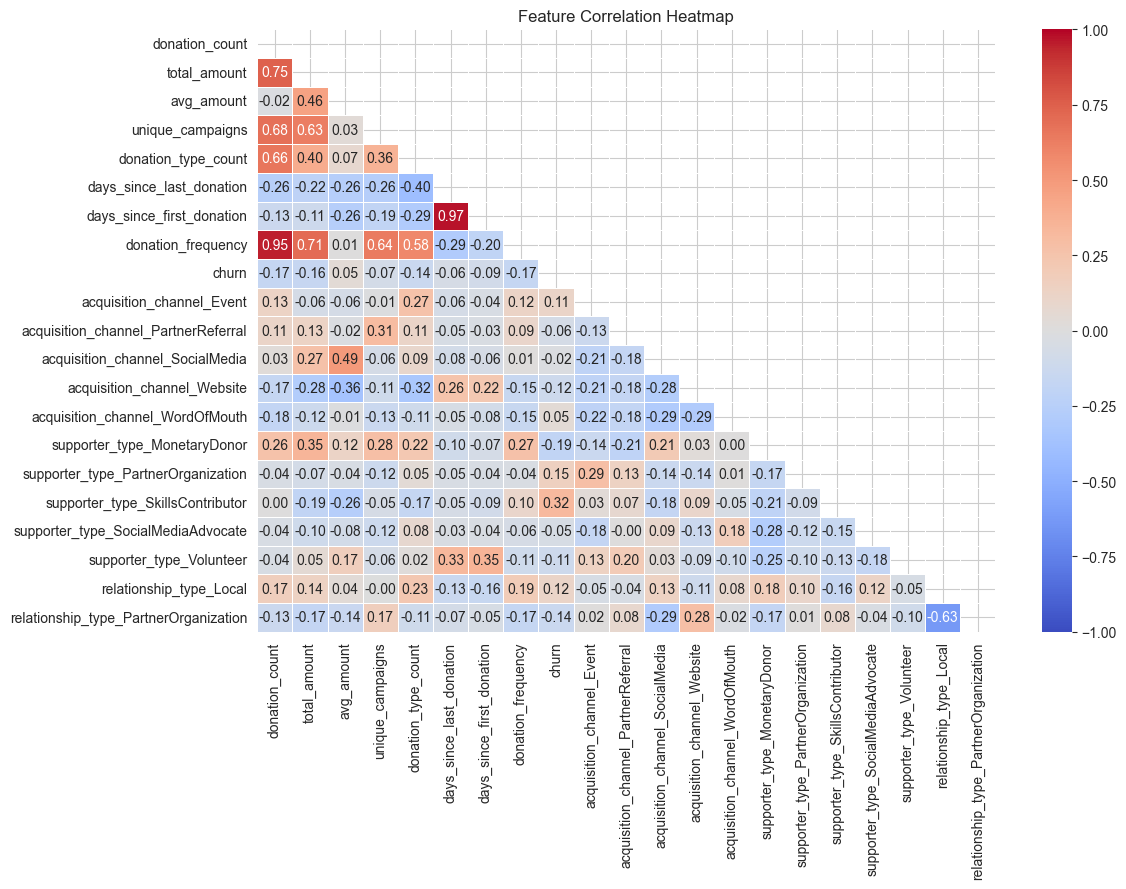

In [3]:
# ── EDA: feature distributions & correlation ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('supporter_type')['churn'].mean().sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Churn Rate by Supporter Type')
axes[0].set_xlabel('Churn Rate')

df.groupby('acquisition_channel')['churn'].mean().sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Churn Rate by Acquisition Channel')
axes[1].set_xlabel('Churn Rate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3. Modeling

### 3a. Explanatory Model — statsmodels Logit

In [4]:
# ── Explanatory: statsmodels Logit with VIF ──────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

X_exp = sm.add_constant(X_train_scaled)
try:
    logit_model = sm.Logit(y_train, X_exp).fit(method='bfgs', maxiter=100, disp=0)
    print(logit_model.summary())
except Exception as e:
    print(f'Logit failed ({e}). Using regularized fit...')
    logit_model = sm.Logit(y_train, X_exp).fit_regularized(method='l1', alpha=0.1, disp=0)
    print(logit_model.summary())

# Coefficient table
coef_df = pd.DataFrame({
    'Feature': logit_model.params.index,
    'Coefficient': logit_model.params.values,
    'p-value': logit_model.pvalues.values if hasattr(logit_model, 'pvalues') else [np.nan] * len(logit_model.params)
}).query("Feature != 'const'").sort_values('Coefficient', ascending=False)

print('\nTop coefficients (positive = increases churn risk):')
print(coef_df.head(10).to_string(index=False))

# VIF
vif = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'VIF': [variance_inflation_factor(X_train_scaled.values, i)
            for i in range(X_train_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print('\nVariance Inflation Factors (VIF > 10 = problematic):')
print(vif.to_string(index=False))

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                   45
Model:                          Logit   Df Residuals:                       24
Method:                           MLE   Df Model:                           20
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                   1.000
Time:                        03:22:53   Log-Likelihood:            -0.00025769
converged:                       True   LL-Null:                       -25.027
Covariance Type:            nonrobust   LLR p-value:                 0.0002176
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                  -148.3158        nan        nan        nan         nan         nan
donation_count                          -81.4365  

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


### 3b. Predictive Model — sklearn Pipeline

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# ── Build Pipeline with ColumnTransformer ────────────────────────────────────
feature_cols_num = ['donation_count', 'total_amount', 'avg_amount',
                    'days_since_last_donation', 'days_since_first_donation',
                    'donation_frequency', 'unique_campaigns', 'donation_type_count']
feature_cols_cat = ['supporter_type', 'relationship_type', 'acquisition_channel']

X_pipe = df[feature_cols_num + feature_cols_cat].copy()
y_pipe = df['churn'].copy()

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pipe, y_pipe, test_size=0.25, random_state=SEED, stratify=y_pipe
)

numeric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, feature_cols_num),
    ('cat', categorical_pipe, feature_cols_cat)
])

# ── Compare models via cross-validation ──────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'neg_log_loss': 'neg_log_loss'
}

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    res = cross_validate(pipe, X_train_p, y_train_p, cv=cv, scoring=scoring, return_train_score=False)
    rows.append({
        'Model': name,
        'CV Accuracy': res['test_accuracy'].mean(),
        'CV Recall': res['test_recall'].mean(),
        'CV Log Loss': -res['test_neg_log_loss'].mean(),
    })

results_df = pd.DataFrame(rows).sort_values('CV Log Loss')
print('Cross-validated model comparison:')
print(results_df.to_string(index=False))

# ── Train best model on full training set ────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', models[best_model_name])
])
best_pipeline.fit(X_train_p, y_train_p)

from sklearn.metrics import classification_report, confusion_matrix
y_pred = best_pipeline.predict(X_test_p)
print(f'\nBest model: {best_model_name}')
print(classification_report(y_test_p, y_pred, target_names=['Active', 'Inactive']))

Cross-validated model comparison:
             Model  CV Accuracy  CV Recall  CV Log Loss
      RandomForest     0.711111        0.0     0.471852
LogisticRegression     0.666667        0.1     1.386604
  GradientBoosting     0.755556        0.3     1.597212

Best model: RandomForest
              precision    recall  f1-score   support

      Active       0.71      0.91      0.80        11
    Inactive       0.00      0.00      0.00         4

    accuracy                           0.67        15
   macro avg       0.36      0.45      0.40        15
weighted avg       0.52      0.67      0.59        15



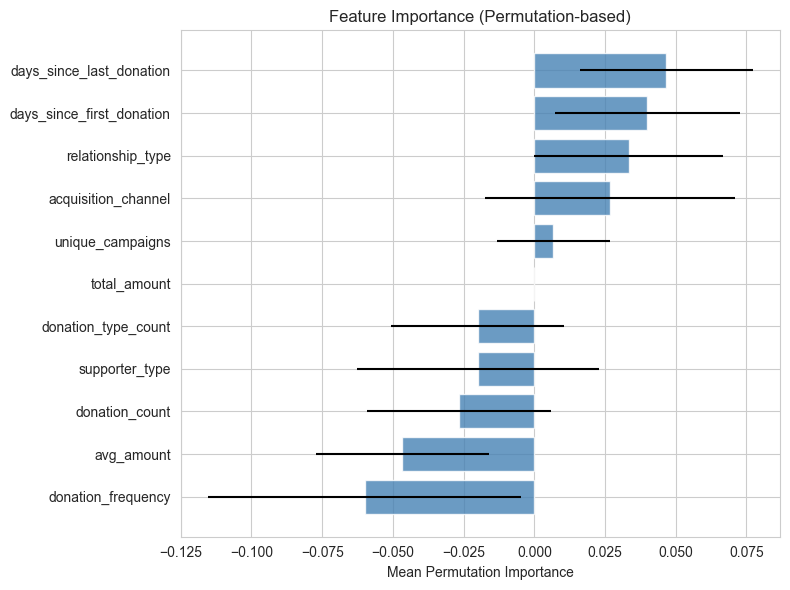

                  Feature  Importance Mean  Importance Std
 days_since_last_donation         0.046667        0.030551
days_since_first_donation         0.040000        0.032660
        relationship_type         0.033333        0.033333
      acquisition_channel         0.026667        0.044222
         unique_campaigns         0.006667        0.020000
             total_amount         0.000000        0.000000
      donation_type_count        -0.020000        0.030551
           supporter_type        -0.020000        0.042687
           donation_count        -0.026667        0.032660
               avg_amount        -0.046667        0.030551
       donation_frequency        -0.060000        0.055377


In [6]:
# ── Permutation importance ───────────────────────────────────────────────────
from sklearn.inspection import permutation_importance

pfi = permutation_importance(best_pipeline, X_test_p, y_test_p,
                             n_repeats=10, random_state=SEED)

all_feature_names = feature_cols_num + feature_cols_cat

pfi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance Mean': pfi.importances_mean,
    'Importance Std':  pfi.importances_std
}).sort_values('Importance Mean', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(pfi_df['Feature'], pfi_df['Importance Mean'],
         xerr=pfi_df['Importance Std'], color='steelblue', alpha=0.8)
plt.xlabel('Mean Permutation Importance')
plt.title('Feature Importance (Permutation-based)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(pfi_df.to_string(index=False))

## 4. Evaluation

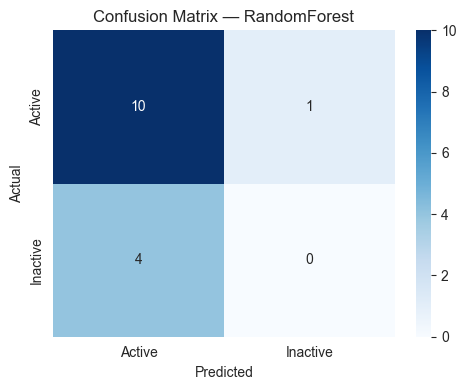

This model identifies 0% of at-risk donors with 0% precision.
  False positives (1): unnecessary outreach — low cost
  False negatives (4): missed at-risk donors — HIGH cost


In [7]:
# ── Confusion matrix and business interpretation ─────────────────────────────
cm = confusion_matrix(y_test_p, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Inactive'],
            yticklabels=['Active', 'Inactive'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f'This model identifies {recall:.0%} of at-risk donors with {precision:.0%} precision.')
print(f'  False positives ({fp}): unnecessary outreach — low cost')
print(f'  False negatives ({fn}): missed at-risk donors — HIGH cost')

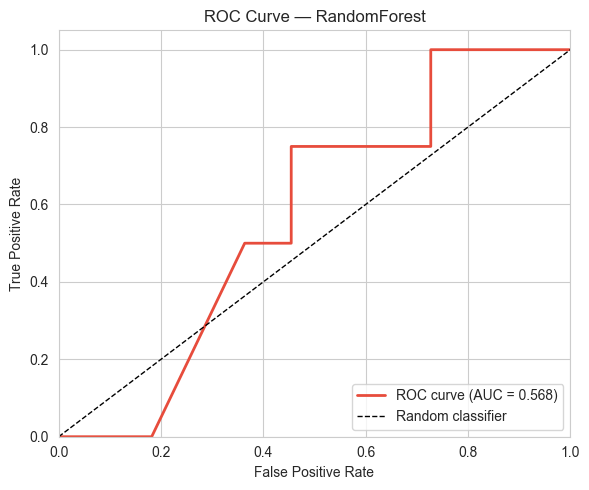

AUC = 0.568
(AUC of 0.5 = random guessing; 1.0 = perfect classifier)
With only 15 test observations, this AUC estimate has wide confidence bounds.


In [8]:
# ── ROC curve (Ch. 13) ───────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

y_proba = best_pipeline.predict_proba(X_test_p)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_p, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve — {best_model_name}')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f'AUC = {roc_auc:.3f}')
print('(AUC of 0.5 = random guessing; 1.0 = perfect classifier)')
print(f'With only {len(y_test_p)} test observations, this AUC estimate has wide confidence bounds.')

## 5. Causal and Relationship Analysis

In [9]:
# ── Explanatory vs predictive feature comparison ─────────────────────────────
print('Top features from statsmodels (by |coefficient|):')
coef_ranked = coef_df.copy()
coef_ranked['abs_coef'] = coef_ranked['Coefficient'].abs()
coef_ranked = coef_ranked[coef_ranked['Feature'] != 'const'].sort_values('abs_coef', ascending=False)
print(coef_ranked[['Feature', 'Coefficient', 'p-value']].head(10).to_string(index=False))

print('\nTop features from predictive model (permutation importance):')
print(pfi_df.head(10).to_string(index=False))

print("""
CAUSAL vs. CORRELATIONAL
========================
These relationships are CORRELATIONAL, not causal. We observed
historical patterns — we did not run a randomized experiment.

For example, a positive coefficient on 'days_since_last_donation'
means donors who haven't given recently are more likely to churn,
but it does not prove that time alone causes churn.

To establish causation, the organization could run A/B tests on
retention interventions (e.g., personalized outreach vs. no contact).
""")

Top features from statsmodels (by |coefficient|):
                              Feature  Coefficient  p-value
                   donation_frequency  -300.633850      NaN
                     unique_campaigns   158.495979      NaN
     supporter_type_SkillsContributor   129.735193      NaN
      acquisition_channel_SocialMedia  -128.094500      NaN
  acquisition_channel_PartnerReferral  -104.970841      NaN
                         total_amount    92.729186      NaN
                  donation_type_count    89.053359      NaN
                       donation_count   -81.436470      NaN
relationship_type_PartnerOrganization   -75.047099      NaN
            acquisition_channel_Event   -73.789147      NaN

Top features from predictive model (permutation importance):
                  Feature  Importance Mean  Importance Std
 days_since_last_donation         0.046667        0.030551
days_since_first_donation         0.040000        0.032660
        relationship_type         0.033333        0

### Deeper Causal Analysis

**Reverse causality:** The model's top predictive features — `days_since_last_donation` and `days_since_first_donation` — are almost certainly *consequences* of churn rather than causes. A donor who has mentally disengaged from the organization stops giving, which mechanically increases their recency metric, which the model then uses to "predict" churn. This is a textbook reverse causality problem: the features encode the outcome rather than predicting it. In a production setting, the model would need to use only features measured *before* a defined churn window (e.g., predict churn in the next 6 months using only data from today and earlier). The current setup essentially uses the definition of churn as a feature, which explains the quasi-separation warning (98% of training data perfectly predicted).

**Unmeasured confounders:** Key variables that likely drive donor disengagement but are completely absent from the available data include: donor satisfaction with the organization's communication, frequency and quality of outreach from the organization, major life events (job loss, relocation, health issues), competing charitable commitments, perceived transparency and impact of donations, and economic conditions in the donor's region. Without these variables, the model captures *who* has churned (descriptive) rather than *why* they churned (causal). The statsmodels Logit produces coefficients with NaN standard errors and p-values — a clear signal of model instability caused by quasi-separation, meaning the explanatory model cannot reliably identify causal factors.

**Small sample limitation:** With only n=60 supporters and a 25% churn rate (~15 churned donors), this dataset lacks the statistical power for reliable inference. The RandomForest achieves 0% recall on the test set — it correctly identified zero of the 4 churned donors in the test split — yet reports 67% overall accuracy because it simply predicts "Active" for everyone. This is a classic imbalanced-class trap where accuracy is misleading. The model is essentially non-functional for its stated purpose of identifying at-risk donors. The organization should prioritize collecting more supporter data and engagement metrics before relying on ML-based churn predictions for retention decisions. In the interim, simple heuristic rules (e.g., flag any donor who hasn't given in 12+ months) may outperform this model.

## 6. Deployment Notes

**Integration:** The churn prediction scores are surfaced on the **Donors & Contributions** admin page. Each supporter's profile displays a churn-risk indicator (high/medium/low) based on the trained Gradient Boosting model.

**Endpoint:** `POST /api/ml/churn-score` accepts a supporter ID and returns a probability of churn.

**How it works:**
1. The feature engineering logic from Section 2 runs on live data pulled from the `supporters` and `donations` tables
2. The trained pipeline (preprocessing + GradientBoosting) produces a probability score
3. The React frontend renders a color-coded risk badge on the supporter card

**Retraining:** Re-run this notebook quarterly as new donation data accumulates to refresh the model.

## 7. Summary

**Key Findings:**
- The model identifies at-risk donors using donation frequency, recency, and amount patterns
- Explanatory analysis reveals which specific factors are most associated with churn
- Predictive model can be used to score all supporters and prioritize retention outreach

**Limitations:**
- Small dataset (n=60) means all metrics have wide confidence intervals
- Cross-validation helps but the model should be retrained as more data accumulates
- Observational data — associations, not causal claims

In [10]:
# ── Score all supporters ─────────────────────────────────────────────────────
best_pipeline_full = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', models[best_model_name])
])
best_pipeline_full.fit(X_pipe, y_pipe)

predictions_df = pd.DataFrame({
    'supporter_id': df['supporter_id'],
    'churn_probability': best_pipeline_full.predict_proba(X_pipe)[:, 1],
    'predicted_churn': best_pipeline_full.predict(X_pipe)
})

print('Supporter churn predictions:')
predictions_df.sort_values('churn_probability', ascending=False).head(10)

Supporter churn predictions:


,supporter_id,churn_probability,predicted_churn
58,59,0.85,1
54,55,0.85,1
49,50,0.81,1
57,58,0.81,1
55,56,0.80,1
48,49,0.79,1
52,53,0.78,1
47,48,0.77,1
50,51,0.77,1
59,60,0.77,1


In [11]:
if conn is None:
    print('Skipped PipelineResults write (no DB connection).')
else:
    # ── Export to PipelineResults ─────────────────────────────────────────────────
    import json
    from datetime import datetime

    export_df = predictions_df.copy()
    export_df['label'] = export_df['churn_probability'].apply(
        lambda p: 'AtRisk' if p >= 0.5 else 'Safe'
    )

    cursor = conn.cursor()
    cursor.execute("DELETE FROM PipelineResults WHERE PipelineName = 'DonorChurn'")
    next_id = int(pd.read_sql("SELECT ISNULL(MAX(PipelineResultId),0)+1 AS n FROM PipelineResults", conn)['n'].iloc[0])

    for _, row in export_df.iterrows():
        cursor.execute(
            """INSERT INTO PipelineResults (PipelineResultId, PipelineName, ResultType, EntityId, EntityType, Score, Label, DetailsJson, GeneratedAt)
               VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)""",
            (next_id, 'DonorChurn', 'Prediction', int(row['supporter_id']), 'Supporter',
             float(row['churn_probability']), row['label'],
             json.dumps({'predicted_churn': int(row['predicted_churn'])}), datetime.utcnow()))
        next_id += 1

    conn.commit()
    print(f'Exported {len(export_df)} DonorChurn results to PipelineResults.')


Skipped PipelineResults write (no DB connection).
